# Coral Reef Bleaching — Model Evaluation
**ML Assignment | Group 10 | SLIIT**

Loads all 4 trained models from Google Drive and evaluates on the same test set.

**Supports:** Pipeline models (LR poly) and standard models (RF, XGBoost, SVM).

**Important:** All temperature values in CUSTOM_INPUT and REEF_SITES use **Kelvin** (297-303K range) to match the training dataset.

## 1. Download Models from Google Drive

In [1]:
import os, subprocess, sys, shutil

GDRIVE_FOLDER_ID = '1pQVpg-ne5EJzaL0BDooCKKvIBquaeIUm'

def download_models_from_gdrive():
    # Always wipe old files first — prevents Drive file ID caching serving stale models
    if os.path.exists('models'):
        shutil.rmtree('models')
        print('Cleared old models/ folder')
    if os.path.exists('gdrive_models'):
        shutil.rmtree('gdrive_models')
    os.makedirs('models', exist_ok=True)

    try:
        import gdown
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gdown', '-q'])
        import gdown

    MODEL_FILES = {
        'lr' : ['lr_model.pkl', 'lr_features.pkl', 'lr_metadata.json'],
        'rf' : ['rf_model.pkl', 'rf_features.pkl', 'rf_metadata.json'],
        'svm': ['svm_model.pkl', 'svm_scaler.pkl', 'svm_features.pkl', 'svm_metadata.json'],
        'xgb': ['xgb_model.pkl', 'xgb_features.pkl', 'xgb_metadata.json'],
    }

    print('Downloading from Google Drive...')
    try:
        gdown.download_folder(
            id=GDRIVE_FOLDER_ID, output='gdrive_models',
            quiet=False, use_cookies=False
        )
        for prefix, files in MODEL_FILES.items():
            src_folder = os.path.join('gdrive_models', prefix)
            for fname in files:
                src = os.path.join(src_folder, fname)
                dst = os.path.join('models', fname)
                if os.path.exists(src):
                    shutil.copy2(src, dst)
                    print(f'  Copied: {fname}')
                else:
                    print(f'  WARNING: {fname} not found in Drive')
        shutil.rmtree('gdrive_models')
    except Exception as e:
        print(f'Download failed: {e}')

    print('\nVerification:')
    for prefix, files in MODEL_FILES.items():
        for fname in files:
            path = f'models/{fname}'
            if os.path.exists(path):
                kb = round(os.path.getsize(path)/1024, 1)
                print(f'  [ok] {path:<45} {kb} KB')
            else:
                print(f'  [MISSING] {path}')

download_models_from_gdrive()

Retrieving folder contents


Retrieving folder 1lPht_Hu8M15CRg_eYDa0SPy_coPBCfcG lr
Processing file 15bjrTrysLQsuNCy3F8zlP0bU76VEQRCv lr_features.pkl
Processing file 1nD8rM9YTf9b5n0hABhhRg-0DAt34MYmD lr_metadata.json
Processing file 1tA4LmhikaODEKpUvt1qnyOB0sE1f-cf0 lr_model.pkl
Retrieving folder 1NaCAT2yGWZPiZh5kkhRFwD4ubkBTpWR6 rf
Retrieving folder 1_qUF6hYfXeNNE6MyJXR2p3gXgJp0lncv RandomForest
Processing file 1QUgegn2PE1Df0PAQN3PvVctn4OvgA2vZ correlation_heatmap.png
Processing file 1JBEV5tF6tPKBMwfRvzx3-wMDSvpkH8em cv_RF.png
Processing file 1i8WymvZDe12xLnLXnBztV7O_iFkYM0w6 eda_overview.png
Processing file 1lC4i6Y4kSTVU7ryEVZzJ5BMHIFF2yjCL results_Random_Forest.png
Processing file 1dVp5u4It9Am9U78Cc_enFbnvZnwV2Bht rf_feature_importance.png
Processing file 1k83RF5uHndCIMxcD5KY-I2FQ8IDtFTTi rf_features.pkl
Processing file 1v9WCtRJYhXBNWX2coGjt5tPM-igaltSm rf_metadata.json
Processing file 1D27EAG5kQbgWixpVlbWzW3ThMg2-MpZr rf_model.pkl
Processing file 13Ht4lzZrIkDVFi07jpqQ0KEo5Th5eyJR y_prob_Random_Forest.npy
Proce

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=15bjrTrysLQsuNCy3F8zlP0bU76VEQRCv
To: /content/gdrive_models/lr/lr_features.pkl
100%|██████████| 271/271 [00:00<00:00, 751kB/s]
Downloading...
From: https://drive.google.com/uc?id=1nD8rM9YTf9b5n0hABhhRg-0DAt34MYmD
To: /content/gdrive_models/lr/lr_metadata.json
100%|██████████| 753/753 [00:00<00:00, 2.23MB/s]
Downloading...
From: https://drive.google.com/uc?id=1tA4LmhikaODEKpUvt1qnyOB0sE1f-cf0
To: /content/gdrive_models/lr/lr_model.pkl
100%|██████████| 3.55k/3.55k [00:00<00:00, 12.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1QUgegn2PE1Df0PAQN3PvVctn4OvgA2vZ
To: /content/gdrive_models/rf/RandomForest/correlation_heatmap.png
100%|██████████| 207k/207k [00:00<00:00, 20.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1JBEV5tF6tPKBMwfRvzx3-wMDSvpkH8em
To: /content/gdrive_models/rf/RandomForest/cv_RF.png
100%|███

  Copied: lr_model.pkl
  Copied: lr_features.pkl
  Copied: lr_metadata.json
  Copied: rf_model.pkl
  Copied: rf_features.pkl
  Copied: rf_metadata.json
  Copied: svm_model.pkl
  Copied: svm_scaler.pkl
  Copied: svm_features.pkl
  Copied: svm_metadata.json
  Copied: xgb_model.pkl
  Copied: xgb_features.pkl
  Copied: xgb_metadata.json

Verification:
  [ok] models/lr_model.pkl                           3.5 KB
  [ok] models/lr_features.pkl                        0.3 KB
  [ok] models/lr_metadata.json                       0.7 KB
  [ok] models/rf_model.pkl                           70615.4 KB
  [ok] models/rf_features.pkl                        0.3 KB
  [ok] models/rf_metadata.json                       0.5 KB
  [ok] models/svm_model.pkl                          1496.9 KB
  [ok] models/svm_scaler.pkl                         1.5 KB
  [ok] models/svm_features.pkl                       0.3 KB
  [ok] models/svm_metadata.json                      0.5 KB
  [ok] models/xgb_model.pkl                


Download completed


## 2. Setup & Imports

In [2]:
import subprocess, sys, os
for pkg in ['scikit-learn','xgboost','pandas','numpy','matplotlib','seaborn','joblib']:
    try: __import__(pkg.replace('-','_'))
    except ImportError:
        subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline  import Pipeline as _SkPipeline
from sklearn.metrics   import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
os.makedirs('outputs', exist_ok=True)
RANDOM_STATE = 42
print('Ready.')

Ready.


## 3. Load All 4 Models

In [3]:
MODEL_PREFIXES = {
    'Logistic Regression' : 'lr',
    'Random Forest'       : 'rf',
    'XGBoost'             : 'xgb',
    'SVM (RBF Kernel)'    : 'svm',
}

MODELS   = {}
SCALERS  = {}
FEATURES = {}
METADATA = {}

for name, prefix in MODEL_PREFIXES.items():
    mpath = f'models/{prefix}_model.pkl'
    fpath = f'models/{prefix}_features.pkl'
    jpath = f'models/{prefix}_metadata.json'
    spath = f'models/{prefix}_scaler.pkl'

    if not os.path.exists(mpath):
        print(f'  SKIPPED {name} -- {mpath} not found')
        continue

    MODELS[name]   = joblib.load(mpath)
    FEATURES[name] = joblib.load(fpath) if os.path.exists(fpath) else []
    SCALERS[name]  = joblib.load(spath) if os.path.exists(spath) else None
    with open(jpath) as f:
        METADATA[name] = json.load(f)

    is_pipe  = isinstance(MODELS[name], _SkPipeline)
    needs_sc = METADATA[name].get('needs_scaling', False)
    size_kb  = round(os.path.getsize(mpath)/1024, 1)
    print(f'  Loaded: {name:<25} '
          f'type={type(MODELS[name]).__name__:<28} '
          f'pipeline={is_pipe} '
          f'needs_scaling={needs_sc} '
          f'size={size_kb}KB')

print(f'\nLoaded {len(MODELS)}/{len(MODEL_PREFIXES)} models')

# Quick LR size check
lr_kb = round(os.path.getsize('models/lr_model.pkl')/1024, 1)
if lr_kb < 2:
    print(f'WARNING: lr_model.pkl is {lr_kb}KB -- likely old broken file in Drive')
    print('         Delete old lr/ files from Drive and re-upload new ones')
else:
    print(f'LR model size {lr_kb}KB -- OK')

  Loaded: Logistic Regression       type=Pipeline                     pipeline=True needs_scaling=False size=3.5KB
  Loaded: Random Forest             type=RandomForestClassifier       pipeline=False needs_scaling=False size=70615.4KB
  Loaded: XGBoost                   type=XGBClassifier                pipeline=False needs_scaling=False size=2927.9KB
  Loaded: SVM (RBF Kernel)          type=SVC                          pipeline=False needs_scaling=True size=1496.9KB

Loaded 4/4 models
LR model size 3.5KB -- OK


## 4. Download Dataset & Rebuild Test Set
Rebuilds the exact same split as training (`random_state=42, stratify=y`).

In [4]:
LOCAL_FILE  = 'global_bleaching_environmental.csv'
PRIMARY_URL = ('https://datadocs.bco-dmo.org/dataset/773466/file/'
               'B11vA82u7y2Owp/global_bleaching_environmental.csv')

def download_dataset():
    if os.path.exists(LOCAL_FILE):
        df = pd.read_csv(LOCAL_FILE, low_memory=False)
        df.replace('nd', np.nan, inplace=True)
        print(f'Loaded: {LOCAL_FILE} ({len(df):,} rows)')
        return df
    print('Downloading from BCO-DMO...')
    try:
        import urllib.request
        urllib.request.urlretrieve(PRIMARY_URL, LOCAL_FILE)
        df = pd.read_csv(LOCAL_FILE, low_memory=False)
        df.replace('nd', np.nan, inplace=True)
        df.to_csv(LOCAL_FILE, index=False)
        print(f'Downloaded: {len(df):,} rows')
        return df
    except Exception as e:
        print('BCO-DMO failed:', e)
    raise FileNotFoundError('Download failed. Place CSV manually.')

df = download_dataset()
df.replace('nd', np.nan, inplace=True)

BLEACH_COL = next(
    (c for c in df.columns if 'percent_bleach' in c.lower()),
    next((c for c in df.columns if 'bleach' in c.lower() and
          pd.to_numeric(df[c], errors='coerce').notna().mean() > 0.3), None))
df[BLEACH_COL] = pd.to_numeric(df[BLEACH_COL], errors='coerce')
df.dropna(subset=[BLEACH_COL], inplace=True)
TARGET = 'Bleaching_Binary'
df[TARGET] = (df[BLEACH_COL] > 0).astype(int)

CANDIDATES = [
    'ClimSST','Temperature_Mean','Temperature_Minimum','Temperature_Maximum',
    'SSTA','SSTA_DHW','TSA','TSA_DHW','TSA_DHW_Frequency',
    'Windspeed','SSTA_Frequency','SSTA_Frequency_Standard_Deviation',
    'Turbidity_ct','Turbidity','Cyclone_Frequency',
    'Distance','Depth','Latitude_Degrees','Longitude_Degrees','Date_Year',
]
ALL_FEATURES = [c for c in CANDIDATES if c in df.columns and
                pd.to_numeric(df[c], errors='coerce').notna().mean() > 0.2]

df_m = df[ALL_FEATURES + [TARGET]].copy()
for col in ALL_FEATURES:
    df_m[col] = pd.to_numeric(df_m[col], errors='coerce')
    if df_m[col].isnull().any():
        df_m[col].fillna(df_m[col].median(), inplace=True)
for col in ALL_FEATURES:
    Q1, Q3 = df_m[col].quantile(0.25), df_m[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR > 0:
        df_m[col] = df_m[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

corr  = df_m[ALL_FEATURES].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.97)]
if to_drop:
    ALL_FEATURES = [f for f in ALL_FEATURES if f not in to_drop]
    df_m.drop(columns=to_drop, inplace=True)

from sklearn.model_selection import train_test_split
X_all = df_m[ALL_FEATURES]
y_all = df_m[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Bleaching rate -- test: {y_test.mean()*100:.1f}%')
print(f'Features ({len(ALL_FEATURES)}): {ALL_FEATURES}')

# Show actual temperature range so we know it is Kelvin
if 'Temperature_Mean' in ALL_FEATURES:
    t_min = X_train['Temperature_Mean'].min()
    t_max = X_train['Temperature_Mean'].max()
    unit  = 'Kelvin' if t_min > 200 else 'Celsius'
    print(f'Temperature_Mean range: {t_min:.1f} to {t_max:.1f} ({unit})')

Downloaded: 41,361 rows
Train: 27,612 | Test: 6,903
Bleaching rate -- test: 51.8%
Features (16): ['ClimSST', 'Temperature_Mean', 'Temperature_Minimum', 'Temperature_Maximum', 'SSTA', 'SSTA_DHW', 'TSA', 'TSA_DHW', 'Windspeed', 'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'Turbidity', 'Cyclone_Frequency', 'Latitude_Degrees', 'Longitude_Degrees', 'Date_Year']
Temperature_Mean range: 297.0 to 303.5 (Kelvin)


## 5. Feature Lookup & Universal Predict Helper
`predict_with_model()` handles both Pipeline (LR) and standard models (RF, XGB, SVM).

In [5]:
# Build per-model feature list from metadata
FEAT_DICT = {}
for name, meta in METADATA.items():
    FEAT_DICT[name] = meta.get('features', FEATURES.get(name, ALL_FEATURES))

print('Feature lookup:')
for name, feats in FEAT_DICT.items():
    print(f'  {name:<25}: {len(feats)} features')


def predict_with_model(name, model, X_raw_df):
    """
    Universal predict — works for Pipeline (LR) and standard models.
    Pipeline (LR poly): pass raw DataFrame directly.
    Standard (RF/XGB/SVM): apply scaler if needed, pass numpy array.
    """
    feats    = FEAT_DICT[name]
    scaler   = SCALERS[name]
    needs_sc = METADATA[name].get('needs_scaling', scaler is not None)

    # Align columns to what the model was trained on
    cols = [f for f in feats if f in X_raw_df.columns]
    X    = X_raw_df[cols].copy()

    if isinstance(model, _SkPipeline):
        # Pipeline: scaler + poly + LR all inside -- pass raw DataFrame
        pass
    elif needs_sc and scaler is not None:
        n_exp = scaler.n_features_in_
        if X.shape[1] != n_exp:
            # Pad missing features with 0
            X_full = pd.DataFrame(0.0, index=X.index, columns=feats)
            for c in cols:
                X_full[c] = X[c].values
            X = scaler.transform(X_full.values)
        else:
            X = scaler.transform(X.values)
    else:
        X = X.values

    y_pred = np.array(model.predict(X))
    y_prob = np.array(model.predict_proba(X)[:, 1])
    return y_pred, y_prob


print('predict_with_model() ready.')

Feature lookup:
  Logistic Regression      : 16 features
  Random Forest            : 16 features
  XGBoost                  : 16 features
  SVM (RBF Kernel)         : 16 features
predict_with_model() ready.


## 6. Evaluate All 4 Models on Test Set

In [6]:
RESULTS = {}

for name, model in MODELS.items():
    y_pred, y_prob = predict_with_model(name, model, X_test)
    yt = y_test.values

    acc  = round(accuracy_score(yt, y_pred), 4)
    prec = round(precision_score(yt, y_pred, zero_division=0), 4)
    rec  = round(recall_score(yt, y_pred, zero_division=0), 4)
    f1   = round(f1_score(yt, y_pred, zero_division=0), 4)
    auc  = round(roc_auc_score(yt, y_prob), 4)

    RESULTS[name] = {
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'Accuracy' : acc,
        'Precision': prec,
        'Recall'   : rec,
        'F1'       : f1,
        'ROC-AUC'  : auc,
    }

    pipe_tag = ' [Pipeline]' if isinstance(model, _SkPipeline) else ''
    print(f'  Evaluated: {name}{pipe_tag} | AUC={auc:.4f} | Acc={acc:.4f}')

print(f'\nEvaluation complete: {len(RESULTS)} models')

  Evaluated: Logistic Regression [Pipeline] | AUC=0.8003 | Acc=0.7423
  Evaluated: Random Forest | AUC=0.9745 | Acc=0.9177
  Evaluated: XGBoost | AUC=0.9683 | Acc=0.9021
  Evaluated: SVM (RBF Kernel) | AUC=0.9285 | Acc=0.8789

Evaluation complete: 4 models


## 7. Algorithm Comparison Table

In [7]:
rows = [[n] + [r[m] for m in ['Accuracy','Precision','Recall','F1','ROC-AUC']]
        for n, r in RESULTS.items()]
df_cmp = pd.DataFrame(rows, columns=['Algorithm','Accuracy','Precision','Recall','F1','ROC-AUC'])
df_cmp = df_cmp.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print('='*75)
print('  ALGORITHM COMPARISON TABLE')
print('='*75)
print(df_cmp.to_string(index=False))
print('='*75)
df_cmp.to_csv('outputs/comparison_table.csv', index=False)
print('Saved: outputs/comparison_table.csv')

  ALGORITHM COMPARISON TABLE
          Algorithm  Accuracy  Precision  Recall     F1  ROC-AUC
      Random Forest    0.9177     0.9249  0.9156 0.9202   0.9745
            XGBoost    0.9021     0.9103  0.8996 0.9049   0.9683
   SVM (RBF Kernel)    0.8789     0.8928  0.8708 0.8817   0.9285
Logistic Regression    0.7423     0.7843  0.6933 0.7360   0.8003
Saved: outputs/comparison_table.csv


## 8. Confusion Matrices — All 4 Models

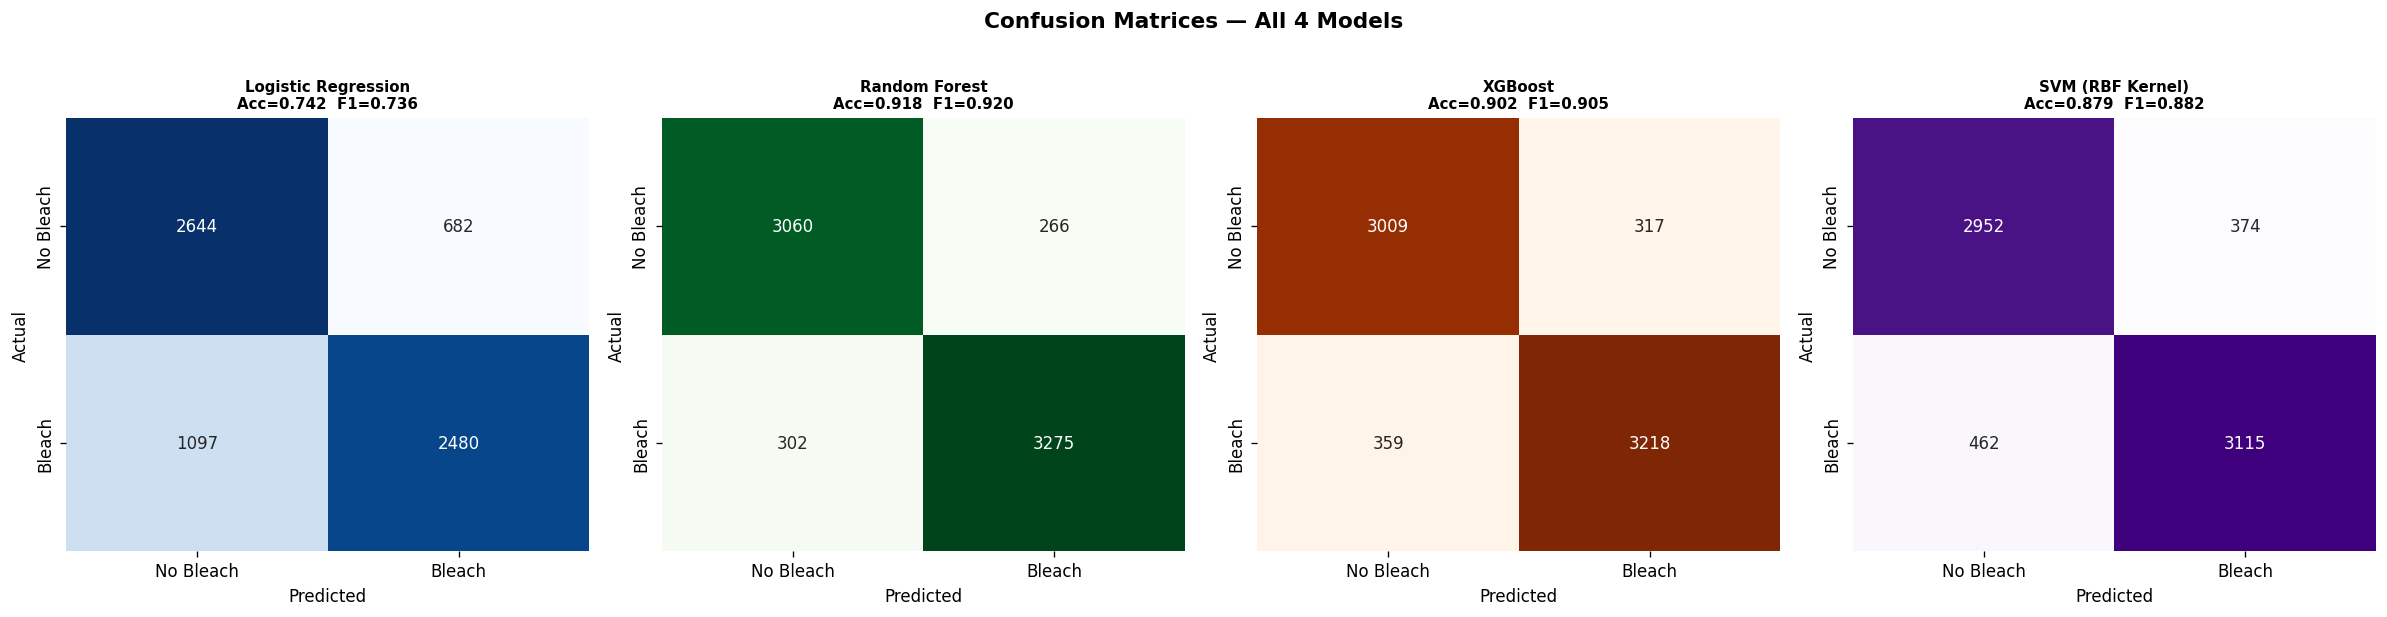

Saved: outputs/eval_confusion_matrices.png


In [8]:
n = len(RESULTS)
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1: axes = [axes]

cmaps = {
    'Logistic Regression' : 'Blues',
    'Random Forest'       : 'Greens',
    'XGBoost'             : 'Oranges',
    'SVM (RBF Kernel)'    : 'Purples',
}

for ax, (name, res) in zip(axes, RESULTS.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmaps.get(name, 'Greens'),
                xticklabels=['No Bleach','Bleach'],
                yticklabels=['No Bleach','Bleach'],
                ax=ax, cbar=False)
    acc = res['Accuracy']
    f1  = res['F1']
    ax.set_title(f'{name}\nAcc={acc:.3f}  F1={f1:.3f}',
                 fontweight='bold', fontsize=9)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — All 4 Models',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/eval_confusion_matrices.png', bbox_inches='tight')
plt.show()
print('Saved: outputs/eval_confusion_matrices.png')

## 9. Combined ROC Curves — All 4 Models

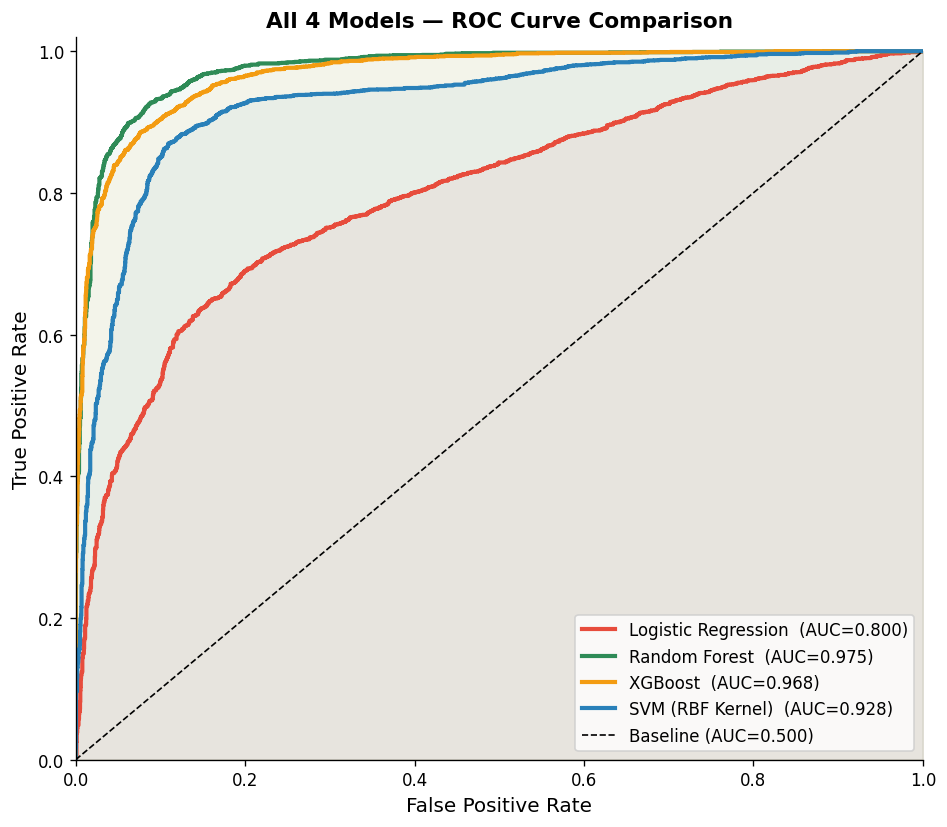

Saved: outputs/eval_roc_curves.png


In [9]:
COLORS = {
    'Logistic Regression' : '#E74C3C',
    'Random Forest'       : '#2E8B57',
    'XGBoost'             : '#F39C12',
    'SVM (RBF Kernel)'    : '#2980B9',
}

plt.figure(figsize=(8, 7))

for name, res in RESULTS.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc = res['ROC-AUC']
    plt.plot(fpr, tpr, lw=2.5, color=COLORS.get(name, '#333'),
             label=f'{name}  (AUC={auc:.3f})')
    plt.fill_between(fpr, tpr, alpha=0.05, color=COLORS.get(name, '#333'))

plt.plot([0,1],[0,1],'k--',lw=1,label='Baseline (AUC=0.500)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('All 4 Models — ROC Curve Comparison',
          fontweight='bold', fontsize=13)
plt.legend(loc='lower right', fontsize=10)
plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.tight_layout()
plt.savefig('outputs/eval_roc_curves.png', bbox_inches='tight')
plt.show()
print('Saved: outputs/eval_roc_curves.png')

## 10. All Metrics — Side by Side Bar Chart

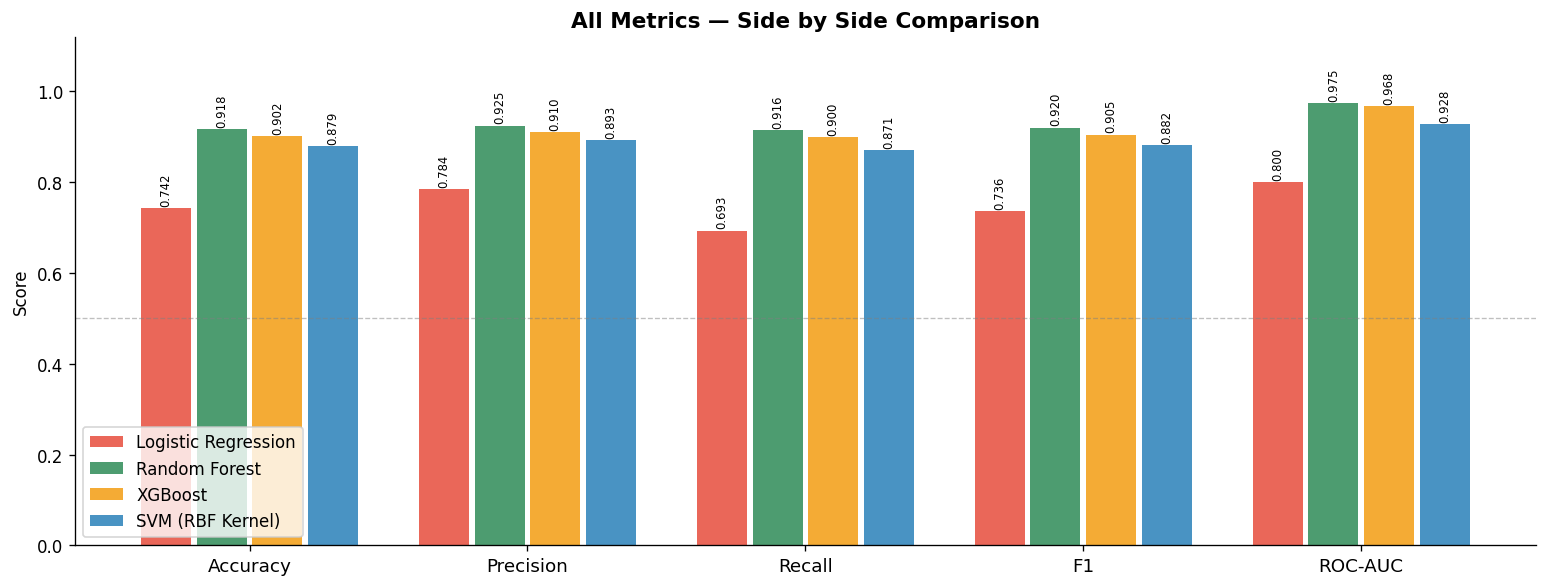

Saved: outputs/eval_metric_bars.png


In [10]:
metrics = ['Accuracy','Precision','Recall','F1','ROC-AUC']
names   = list(RESULTS.keys())
x       = np.arange(len(metrics))
width   = 0.8 / len(names)

fig, ax = plt.subplots(figsize=(13, 5))

for i, (name, res) in enumerate(RESULTS.items()):
    vals   = [res[m] for m in metrics]
    offset = (i - len(names)/2 + 0.5) * width
    bars   = ax.bar(x + offset, vals, width*0.9,
                    label=name,
                    color=list(COLORS.values())[i],
                    alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{v:.3f}',
                ha='center', va='bottom', fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('All Metrics — Side by Side Comparison',
             fontweight='bold', fontsize=13)
ax.legend()
ax.axhline(0.5, color='grey', ls='--', lw=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig('outputs/eval_metric_bars.png', bbox_inches='tight')
plt.show()
print('Saved: outputs/eval_metric_bars.png')

## 11. Custom Single Prediction
**All temperatures in Kelvin** (dataset stores temps in Kelvin, not Celsius).
297K = 24C, 300K = 27C, 303K = 30C, 306K = 33C

In [11]:
# ── Temperature reference (Kelvin) ───────────────────────────────────────────
# 297K = ~24C   |   300K = ~27C   |   303K = ~30C   |   306K = ~33C
# TSA_DHW range in training data: 0.00 to 2.97

CUSTOM_INPUT = {
    'ClimSST'                          : 299.5,   # ~26C baseline SST
    'Temperature_Mean'                 : 302.0,   # ~29C mean temp
    'Temperature_Minimum'              : 299.0,   # ~26C min
    'Temperature_Maximum'              : 303.5,   # ~30C max
    'SSTA'                             : 1.8,     # positive anomaly
    'SSTA_DHW'                         : 2.5,     # degree heating weeks
    'TSA'                              : 2.1,     # thermal stress anomaly
    'TSA_DHW'                          : 2.5,     # within training range 0-2.97
    'TSA_DHW_Frequency'                : 0.3,
    'Windspeed'                        : 4.5,
    'SSTA_Frequency'                   : 0.4,
    'SSTA_Frequency_Standard_Deviation': 0.2,
    'Turbidity_ct'                     : 0.05,
    'Turbidity'                        : 0.05,
    'Cyclone_Frequency'                : 0.1,
    'Distance'                         : 12.0,
    'Depth'                            : 5.0,
    'Latitude_Degrees'                 : -18.0,
    'Longitude_Degrees'                : 147.0,
    'Date_Year'                        : 2016,
}

X_custom = pd.DataFrame([CUSTOM_INPUT])

print('='*58)
print('  CUSTOM PREDICTION')
print('='*58)

votes    = 0
avg_prob = []

for name, model in MODELS.items():
    y_pred, y_prob = predict_with_model(name, model, X_custom)
    pred = int(y_pred[0])
    prob = float(y_prob[0])
    votes    += pred
    avg_prob.append(prob)
    label = 'BLEACHING LIKELY' if pred == 1 else 'NO BLEACHING'
    bar   = chr(9608)*int(prob*20) + chr(9617)*(20 - int(prob*20))
    print(f'  {name:<25} [{bar}] {prob*100:5.1f}%  ->  {label}')

print('-'*58)
print(f'  Votes    : {votes}/{len(MODELS)}')
print(f'  Avg prob : {np.mean(avg_prob)*100:.1f}%')
if   votes >= 3: print('  CONSENSUS: HIGH BLEACHING RISK')
elif votes >= 2: print('  CONSENSUS: MODERATE RISK')
else:            print('  CONSENSUS: LOW / NO RISK')
print('='*58)

  CUSTOM PREDICTION
  Logistic Regression       [███████████████████░]  99.7%  ->  BLEACHING LIKELY
  Random Forest             [████████████░░░░░░░░]  61.8%  ->  BLEACHING LIKELY
  XGBoost                   [████████████████░░░░]  83.1%  ->  BLEACHING LIKELY
  SVM (RBF Kernel)          [█████████████░░░░░░░]  67.9%  ->  BLEACHING LIKELY
----------------------------------------------------------
  Votes    : 4/4
  Avg prob : 78.1%
  CONSENSUS: HIGH BLEACHING RISK


## 12. Batch Prediction — Sample Reef Sites
All temperatures in **Kelvin** to match the training dataset.

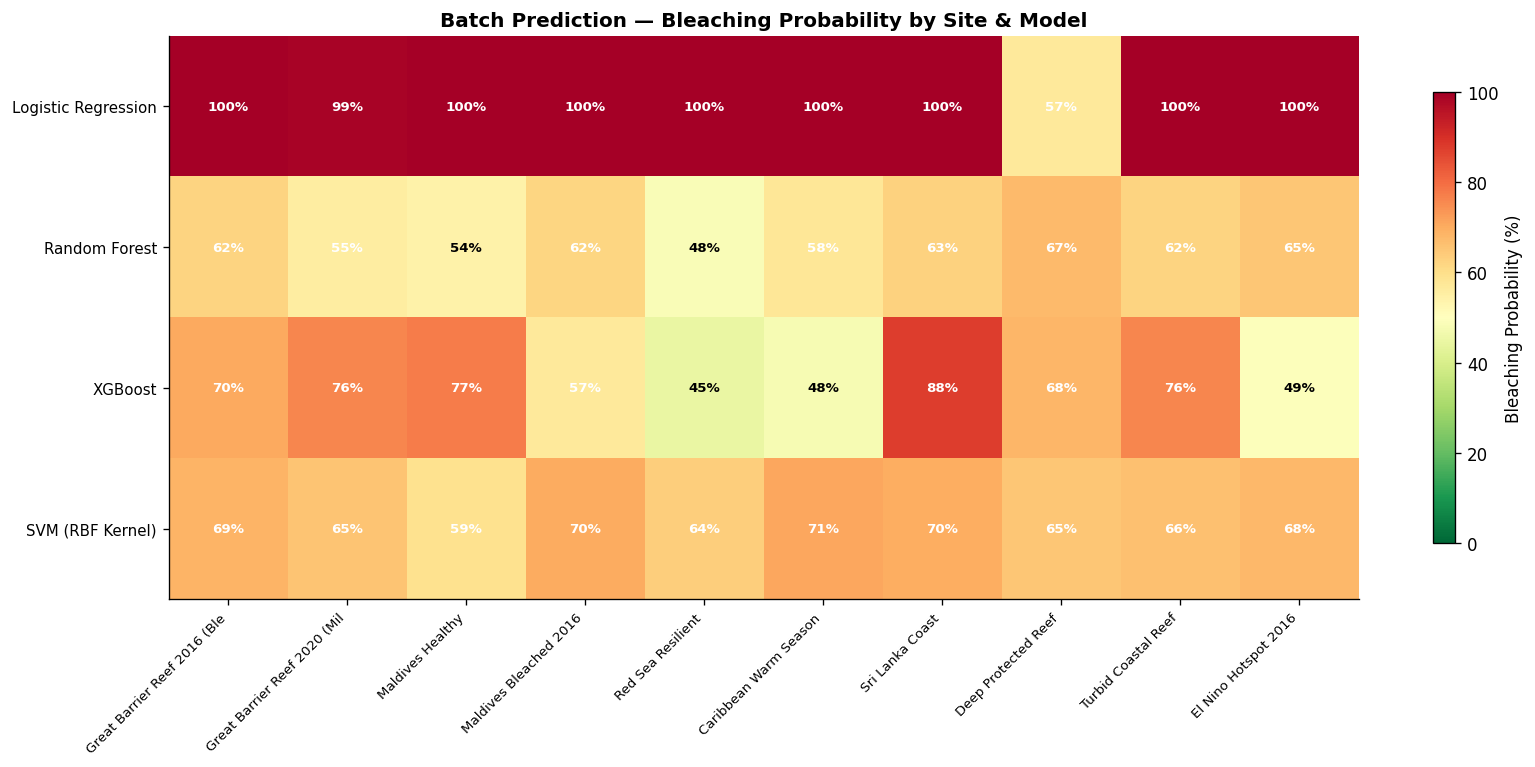

Saved: outputs/eval_batch_heatmap.png


In [12]:
# ── Reef site data — temperatures in KELVIN ──────────────────────────────────
# Format: (name, ClimSST, Temp_Mean, Temp_Min, Temp_Max, SSTA, SSTA_DHW, TSA,
#          TSA_DHW, TSA_DHW_Freq, Windspeed, SSTA_Freq, SSTA_Freq_Std,
#          Turbidity_ct, Turbidity, Cyclone_Freq, Distance, Depth, Lat, Lon, Year)

REEF_SITES = [
    ('Great Barrier Reef 2016 (Bleach)',
     299.5, 302.0, 298.5, 303.5, 2.1, 2.5, 2.5, 2.5, 0.30,
     4.2, 0.40, 0.20, 0.04, 0.04, 0.10, 15.0, 5.0,  -18.3, 147.2, 2016),
    ('Great Barrier Reef 2020 (Mild)',
     299.5, 300.5, 297.8, 302.0, 0.8, 1.2, 1.0, 1.2, 0.12,
     5.1, 0.20, 0.10, 0.05, 0.05, 0.10, 15.0, 5.0,  -18.3, 147.2, 2020),
    ('Maldives Healthy',
     299.8, 300.2, 298.5, 301.5, 0.3, 0.5, 0.4, 0.5, 0.05,
     6.0, 0.10, 0.05, 0.03, 0.03, 0.05, 8.0,  6.0,  4.2,   73.5,  2019),
    ('Maldives Bleached 2016',
     299.8, 302.5, 298.8, 303.8, 2.8, 2.5, 3.1, 2.5, 0.40,
     3.5, 0.50, 0.25, 0.03, 0.03, 0.05, 8.0,  6.0,  4.2,   73.5,  2016),
    ('Red Sea Resilient',
     298.5, 299.0, 297.0, 301.0, 0.1, 0.2, 0.2, 0.2, 0.02,
     7.0, 0.05, 0.03, 0.08, 0.08, 0.02, 20.0, 8.0,  22.5,  37.8,  2018),
    ('Caribbean Warm Season',
     299.3, 301.5, 297.8, 302.8, 1.7, 2.2, 2.0, 2.2, 0.25,
     5.5, 0.35, 0.15, 0.06, 0.06, 0.08, 10.0, 4.0,  17.5,  -66.0, 2015),
    ('Sri Lanka Coast',
     299.6, 301.0, 298.0, 302.5, 1.2, 1.8, 1.5, 1.8, 0.18,
     4.8, 0.25, 0.12, 0.07, 0.07, 0.06, 5.0,  3.0,  6.9,   81.5,  2016),
    ('Deep Protected Reef',
     297.5, 298.0, 296.5, 299.5, -0.2, 0.1, -0.1, 0.1, 0.01,
     8.0, 0.02, 0.01, 0.12, 0.12, 0.01, 30.0, 25.0, -22.0, 114.0, 2017),
    ('Turbid Coastal Reef',
     299.0, 301.2, 297.5, 302.5, 1.9, 2.5, 2.2, 2.5, 0.28,
     3.2, 0.38, 0.18, 0.35, 0.35, 0.09, 2.0,  3.0,  -8.5,  115.2, 2016),
    ('El Nino Hotspot 2016',
     300.5, 302.8, 299.0, 303.8, 2.5, 2.9, 2.8, 2.9, 0.45,
     2.8, 0.55, 0.28, 0.02, 0.02, 0.12, 12.0, 4.0,  -16.0, 145.5, 2016),
]

FEAT_COLS = [
    'ClimSST','Temperature_Mean','Temperature_Minimum','Temperature_Maximum',
    'SSTA','SSTA_DHW','TSA','TSA_DHW','TSA_DHW_Frequency','Windspeed',
    'SSTA_Frequency','SSTA_Frequency_Standard_Deviation','Turbidity_ct',
    'Turbidity','Cyclone_Frequency','Distance','Depth',
    'Latitude_Degrees','Longitude_Degrees','Date_Year',
]

site_labels = [s[0] for s in REEF_SITES]
all_probs   = {n: [] for n in MODELS}

for site in REEF_SITES:
    X_site = pd.DataFrame([dict(zip(FEAT_COLS, site[1:]))])
    for name, model in MODELS.items():
        _, y_prob = predict_with_model(name, model, X_site)
        all_probs[name].append(float(y_prob[0]) * 100)

# ── Heatmap ───────────────────────────────────────────────────────────────────
prob_matrix = np.array([all_probs[n] for n in MODELS])

fig, ax = plt.subplots(figsize=(14, max(5, len(REEF_SITES)*0.65)))
im = ax.imshow(prob_matrix, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=100)

ax.set_xticks(range(len(REEF_SITES)))
ax.set_xticklabels([s[:28] for s in site_labels],
                   rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(MODELS)))
ax.set_yticklabels(list(MODELS.keys()), fontsize=9)

for i in range(len(MODELS)):
    for j in range(len(REEF_SITES)):
        v = prob_matrix[i, j]
        ax.text(j, i, f'{v:.0f}%',
                ha='center', va='center', fontsize=8,
                color='white' if v > 55 else 'black',
                fontweight='bold')

plt.colorbar(im, ax=ax, shrink=0.8, label='Bleaching Probability (%)')
ax.set_title('Batch Prediction — Bleaching Probability by Site & Model',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/eval_batch_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: outputs/eval_batch_heatmap.png')